In [1]:
import sys
sys.path.append('..')
from train.train_utils.latent_sampler import LatentSampler
from util.visualization.utils_mesh import get_watertight_mesh_for_latent
import torch
import numpy as np
import k3d
from tqdm import tqdm
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials

## Compare Original vs SCC Fine-tuned Model

This section loads both models and shows shapes side-by-side.

**SCC Approach (Persistent Homology):**
- Uses `cripser` library for persistent homology computation
- Targets Betti numbers [1, 0, 0] = one connected component, no holes, no voids
- More principled than Morse theory saddle detection
- Previous V2 (Morse theory) FAILED - made shapes MORE fragmented (11 vs 5.1 components)

In [2]:
import sys
sys.path.append('..')
from train.train_utils.latent_sampler import LatentSampler
from util.visualization.utils_mesh import get_watertight_mesh_for_latent
import torch
import numpy as np
import k3d
from tqdm import tqdm
from util.checkpointing import load_yaml_and_drop_keys
from util.get_config import get_config_from_yml
from util.misc import get_model
from models.net_w_partials import NetWithPartials
import trimesh

# Settings
mc_resolution = 128  # Lower for faster comparison
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Load bounds (same for both)
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

# ============================================
# Load ORIGINAL model (using original config)
# Note: Original config has layers=[5,128,128,128,1] which is ALREADY expanded
# So we need to remove input/output before calling get_model
# ============================================
config_orig = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
# Original config has full layers [5,128,128,128,1] - extract hidden only
orig_layers = config_orig['layers'].copy()  
hidden_layers = orig_layers[1:-1]  # Remove first (input) and last (output)
model_original = get_model(
    model_str='cond_wire', 
    nx=config_orig['nx'], 
    nz=config_orig['nz'], 
    layers=hidden_layers.copy(),  # [128, 128, 128] - COPY to avoid in-place modification
    w0=1, 
    w0_initial=18, 
    wire_scale=6, 
    use_legacy_gabor=True,
    return_density=False
)
model_original.load_state_dict(torch.load('../checkpoints/GINN-model.pt', map_location=device))
model_original = model_original.to(device).eval()
netp_original = NetWithPartials.create_from_model(model_original, config_orig['nz'], config_orig['nx'])
print("Original GINN model loaded")

# ============================================
# Load SCC FINE-TUNED model (Persistent Homology approach)
# Uses simjeb_finetune_scc.yml with Betti number targeting
# This approach uses cripser for PH instead of Morse theory
# ============================================
config_ft = get_config_from_yml('../configs/GINN/simjeb_finetune_scc.yml', '../configs/base_config.yml')
model_cfg = config_ft['model']

# IMPORTANT: get_model modifies layers in-place, so we must copy!
model_finetuned = get_model(
    model_str=model_cfg['model_str'],
    nx=model_cfg['nx'],
    nz=model_cfg['nz'],
    layers=model_cfg['layers'].copy(),  # COPY to avoid in-place modification
    w0_initial=model_cfg.get('w0_initial', 30),
    w0=model_cfg.get('w0', 30),
    wire_scale=model_cfg.get('wire_scale', 10),
    return_density=model_cfg.get('return_density', False),
    use_legacy_gabor=model_cfg.get('use_legacy_gabor', False)
)

# SCC checkpoint - trained with Persistent Homology (Betti number targeting)
# Target: [1, 0, 0] = 1 connected component, 0 holes, 0 voids
# 3000 epochs - SCC loss reached 0.0
finetuned_path = '../checkpoints/cond_wire/2026_01_27__21_58_20-bnsrxi2p/2026_01_27__21_58_20-bnsrxi2p-model.pt'
checkpoint = torch.load(finetuned_path, map_location=device)

# Handle different checkpoint formats
if isinstance(checkpoint, dict):
    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

model_finetuned.load_state_dict(state_dict)
model_finetuned = model_finetuned.to(device).eval()
netp_finetuned = NetWithPartials.create_from_model(model_finetuned, config_ft['nz'], config_ft['nx'])
print("SCC Fine-tuned model loaded (Persistent Homology approach)")
print("  Config: simjeb_finetune_scc.yml")
print("  Method: PHManager with cripser (Betti targeting)")
print("  Target: [1,0,0] = single connected component")
print("  Settings: lr=0.0001, lambda_scc=50.0, 3000 epochs")

# Both use the same architecture (nz=2)
print(f"Both models use nz={config_orig['nz']}")
config = config_orig  # Use for latent sampling

Device: cuda


C:\Users\chukw\AppData\Local\Temp\ipykernel_40968\2725093068.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_original.load_state_dict(torch.load('../checkpoints/G

Original GINN model loaded
Overwriting training_mode in base_config with single (was single)
Overwriting w0 in base_config with 1 (was 1.0)
Overwriting train_plot_max_n_shapes in base_config with 9 (was 16)
Overwriting field_losses in base_config with [] (was ['comp', 'vol', 'chamfer_div', 'wasserstein_div'])
Overwriting lambda_connectivity in base_config with 0.0 (was 0)
Overwriting lambda_comp in base_config with 0.0 (was 0)
Overwriting lambda_vol in base_config with 0.0 (was 0)
Overwriting connectivity_n_samples in base_config with 500 (was 1000)
Overwriting connectivity_n_iter in base_config with 30 (was 30)
Overwriting connectivity_grad_tol in base_config with 0.01 (was 0.01)
Overwriting connectivity_update_every_n_epochs in base_config with 20 (was 50)
Overwriting scale_connectivity in base_config with 1.0 (was 1.0)
Overwriting start_connectivity in base_config with 0 (was 1000)
Overwriting curvature_expression in base_config with 4*H**2 - 2*K (was 4*H**2 - 2*K)
Overwriting curva

C:\Users\chukw\AppData\Local\Temp\ipykernel_40968\2725093068.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(finetuned_path, map_location=device

In [3]:
# Generate random latent vectors for comparison
# Test WIDER z range to find where original model has issues
n_compare = 20
torch.manual_seed(42)

# Test across full z range [0, 1] - not just [0, 0.1]
z_min, z_max = 0, 0.1
z_latents = torch.rand(n_compare, config['nz'], device=device) * (z_max - z_min) + z_min

print(f"Comparing {n_compare} shapes with z in [{z_min}, {z_max}] (FULL RANGE)")
print(f"Sample z values:")
for i in range(min(5, n_compare)):
    print(f"  Shape {i+1}: z = {z_latents[i].tolist()}")

Comparing 20 shapes with z in [0, 0.1] (FULL RANGE)
Sample z values:
  Shape 1: z = [0.06129598617553711, 0.0010058844927698374]
  Shape 2: z = [0.03984136879444122, 0.004030840005725622]
  Shape 3: z = [0.01562667451798916, 0.048247307538986206]
  Shape 4: z = [0.07362473011016846, 0.04059819504618645]
  Shape 5: z = [0.05188996344804764, 0.028671110048890114]


In [4]:
# DEBUG: Verify models are different and weights were loaded correctly
print("DEBUG: Checking model weights...")

# Get first layer weights from both models
orig_w = list(model_original.parameters())[0]
ft_w = list(model_finetuned.parameters())[0]

print(f"Original model first param shape: {orig_w.shape}")
print(f"Fine-tuned model first param shape: {ft_w.shape}")

# Check if weights are identical
weights_equal = torch.allclose(orig_w, ft_w, atol=1e-6)
print(f"Weights are identical: {weights_equal}")

# Compute weight difference
weight_diff = (orig_w - ft_w).abs().mean().item()
print(f"Mean absolute weight difference: {weight_diff:.6f}")

# Check a sample point - model takes (x, z) separately
test_x = torch.tensor([[0.0, 0.0, 0.0]], device=device)  # x,y,z
test_z = torch.tensor([[0.05, 0.05]], device=device)     # z_latent
with torch.no_grad():
    out_orig = model_original(test_x, test_z)
    out_ft = model_finetuned(test_x, test_z)
print(f"\nTest input x: {test_x.tolist()}, z: {test_z.tolist()}")
print(f"Original output: {out_orig.item():.6f}")
print(f"Fine-tuned output: {out_ft.item():.6f}")
print(f"Output difference: {(out_orig - out_ft).abs().item():.6f}")

DEBUG: Checking model weights...
Original model first param shape: torch.Size([128, 5])
Fine-tuned model first param shape: torch.Size([128, 5])
Weights are identical: False
Mean absolute weight difference: 0.026694

Test input x: [[0.0, 0.0, 0.0]], z: [[0.05000000074505806, 0.05000000074505806]]
Original output: -0.072201
Fine-tuned output: 0.004061
Output difference: 0.076262


In [5]:
# Extract meshes from both models and count components
print("Extracting meshes...")
print(f"{'Shape':<8} {'Original':<25} {'Fine-tuned':<25}")
print("-" * 60)
results = []

for i, z in enumerate(tqdm(z_latents)):
    # Original model
    mesh_orig = get_watertight_mesh_for_latent(
        netp_original.f_, netp_original.params, z, bounds, mc_resolution, device,
        chunks=1, level=0, surpress_watertight=True
    )
    
    # Fine-tuned model
    mesh_ft = get_watertight_mesh_for_latent(
        netp_finetuned.f_, netp_finetuned.params, z, bounds, mc_resolution, device,
        chunks=1, level=0, surpress_watertight=True
    )
    
    # Count components
    def count_components(mesh_tuple):
        verts, faces = mesh_tuple
        if len(verts) == 0 or len(faces) == 0:
            return 0, 0
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            return len(tm.split(only_watertight=False)), len(verts)
        except:
            return -1, len(verts)
    
    n_orig, v_orig = count_components(mesh_orig)
    n_ft, v_ft = count_components(mesh_ft)
    
    results.append({
        'z': z,
        'mesh_orig': mesh_orig,
        'mesh_ft': mesh_ft,
        'n_components_orig': n_orig,
        'n_components_ft': n_ft,
        'n_vertices_orig': v_orig,
        'n_vertices_ft': v_ft
    })
    
    status_orig = f"{'✓' if n_orig == 1 else '✗'} {n_orig} comp, {v_orig} verts"
    status_ft = f"{'✓' if n_ft == 1 else '✗'} {n_ft} comp, {v_ft} verts"
    print(f"{i+1:<8} {status_orig:<25} {status_ft:<25}")

Extracting meshes...
Shape    Original                  Fine-tuned               
------------------------------------------------------------


 10%|█         | 2/20 [00:00<00:04,  4.47it/s]

1        ✓ 1 comp, 11838 verts     ✓ 1 comp, 16016 verts    
2        ✓ 1 comp, 15166 verts     ✓ 1 comp, 16654 verts    


 15%|█▌        | 3/20 [00:00<00:03,  4.69it/s]

3        ✓ 1 comp, 18402 verts     ✓ 1 comp, 18064 verts    
4        ✓ 1 comp, 16340 verts     ✗ 5 comp, 16778 verts    


...

 90%|█████████ | 18/20 [00:03<00:00,  5.33it/s]

17       ✓ 1 comp, 15210 verts     ✓ 1 comp, 16606 verts    
18       ✓ 1 comp, 14396 verts     ✓ 1 comp, 18442 verts    


100%|██████████| 20/20 [00:03<00:00,  5.35it/s]

19       ✓ 1 comp, 17532 verts     ✓ 1 comp, 17318 verts    
20       ✓ 1 comp, 13842 verts     ✓ 1 comp, 18344 verts    


100%|██████████| 20/20 [00:03<00:00,  5.18it/s]


### Visual Comparison: Original (Blue) vs Fine-tuned (Green)

Left column = Original GINN (often disconnected)  
Right column = Fine-tuned with connectivity (more connected)

In [6]:
# Summary statistics
n_connected_orig = sum(1 for r in results if r['n_components_orig'] == 1)
n_connected_ft = sum(1 for r in results if r['n_components_ft'] == 1)

# Filter for valid shapes (has vertices)
valid_orig = [r for r in results if r['n_vertices_orig'] > 0]
valid_ft = [r for r in results if r['n_vertices_ft'] > 0]

avg_comp_orig = np.mean([r['n_components_orig'] for r in valid_orig]) if valid_orig else 0
avg_comp_ft = np.mean([r['n_components_ft'] for r in valid_ft]) if valid_ft else 0
avg_verts_orig = np.mean([r['n_vertices_orig'] for r in valid_orig]) if valid_orig else 0
avg_verts_ft = np.mean([r['n_vertices_ft'] for r in valid_ft]) if valid_ft else 0

print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"                    Original        Fine-tuned")
print(f"Valid shapes:       {len(valid_orig):<15} {len(valid_ft)}")
print(f"Connected (1 comp): {n_connected_orig:<15} {n_connected_ft}")
print(f"Avg components:     {avg_comp_orig:<15.2f} {avg_comp_ft:.2f}")
print(f"Avg vertices:       {avg_verts_orig:<15.0f} {avg_verts_ft:.0f}")
print(f"{'='*60}")

if avg_verts_ft < 100:
    print("\n⚠️  WARNING: Fine-tuned model produces very small meshes!")
    print("   This suggests the model may have collapsed during training.")
    print("   The connectivity improvement may be due to degenerate shapes.")


SUMMARY
                    Original        Fine-tuned
Valid shapes:       20              20
Connected (1 comp): 20              19
Avg components:     1.00            1.20
Avg vertices:       14402           17114


In [7]:
# Visualize first 4 shapes side by side to see what's happening
n_show = min(4, len(results))
spacing_x = 2.5
spacing_z = 2.0

fig = k3d.plot(height=800)

for i in range(n_show):
    res = results[i]
    
    # Original (left, blue/red)
    if len(res['mesh_orig'][0]) > 0:
        color_orig = 0x3498db if res['n_components_orig'] == 1 else 0xe74c3c
        fig += k3d.mesh(
            *res['mesh_orig'], 
            color=color_orig, 
            side='double',
            translation=[-spacing_x/2, 0, i * spacing_z],
            name=f"Orig #{i+1}: {res['n_components_orig']} comp"
        )
    
    # Fine-tuned (right, green/orange)  
    if len(res['mesh_ft'][0]) > 0:
        color_ft = 0x2ecc71 if res['n_components_ft'] == 1 else 0xf39c12
        fig += k3d.mesh(
            *res['mesh_ft'], 
            color=color_ft, 
            side='double',
            translation=[spacing_x/2, 0, i * spacing_z],
            name=f"FT #{i+1}: {res['n_components_ft']} comp"
        )

fig += k3d.text2d("LEFT=Original | RIGHT=Fine-tuned", position=[0.3, 0.95], size=1.5, color=0x000000)
fig.display()
print("Blue/Green = connected (1 component), Red/Orange = disconnected (>1 component)")

c:\Users\chukw\Desktop\Programming\GINNs-Geometry-informed-Neural-Networks\.venv\Lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

Blue/Green = connected (1 component), Red/Orange = disconnected (>1 component)


#### Load model and create latents

In [8]:
mc_resolution = 248
device = 'cuda' if torch.cuda.is_available() else 'cpu'
n_shapes = 9

# Parameters
config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

## MODEL
model = get_model(**config['model'], use_legacy_gabor=True)
model.load_state_dict(state_dict=torch.load('../checkpoints/GINN-model.pt', map_location=device))
model = model.to(device)

# to handle derivatives of the model we created an abstraction called `NetWithPartials`
netp = NetWithPartials.create_from_model(model, config['nz'], config['nx'])
lat_sampler = LatentSampler(**config['latent_sampling'])
z_latents = lat_sampler.val_z()
print(f'z_latents: {z_latents}')

z_latents: tensor([[0.0000, 0.0000],
        [0.0000, 0.0500],
        [0.0000, 0.1000],
        [0.0500, 0.0000],
        [0.0500, 0.0500],
        [0.0500, 0.1000],
        [0.1000, 0.0000],
        [0.1000, 0.0500],
        [0.1000, 0.1000]])


C:\Users\chukw\AppData\Local\Temp\ipykernel_40968\2335717670.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(state_dict=torch.load('../checkpoints

#### Generate a Custom Shape

In [9]:
# Create a custom latent vector - needs to match nz dimensions from config
# I'll pick z=[0.42, 0.58] to get an interesting shape in the latent space
nz = config['nz']
print(f"Latent dimension nz = {nz}")
custom_z = torch.tensor([0.42, 0.58][:nz], device=device)  # Slice to match nz

# Extract mesh for this custom latent
print(f"Generating shape for z = {custom_z.tolist()}")
custom_mesh = get_watertight_mesh_for_latent(
    netp.f_, netp.params, custom_z, bounds, mc_resolution, device,
    chunks=1, level=0, surpress_watertight=True
)

# Visualize the custom shape
fig_custom = k3d.plot(height=600)
fig_custom += k3d.mesh(*custom_mesh, color=0x3498db, side='double')  # Nice blue color
fig_custom.display()
print(f"Custom shape generated with z = {custom_z.tolist()}")

Latent dimension nz = 2
Generating shape for z = [0.41999998688697815, 0.5799999833106995]


Output()

Custom shape generated with z = [0.41999998688697815, 0.5799999833106995]


#### Extract meshes

In [10]:
## visualize shapes for a range of z
meshes = []
for z in tqdm(z_latents): ## do marching cubes for every z
    z = z.to(device)  # Ensure z is on the same device as the model
    meshes.append(get_watertight_mesh_for_latent(netp.f_, netp.params, z, bounds, mc_resolution, device, 
                                                 chunks=1, level=0,
                                                 surpress_watertight=True))

100%|██████████| 9/9 [00:24<00:00,  2.74s/it]


#### Visualize meshes

In [11]:
spacing = 1.5*(bounds[:,1] - bounds[:,0]).cpu().numpy() ## distances between the shape center to plot in a grid (1.5 times the shape bounding box)
n_rows, n_cols = config['latent_sampling']['val_plot_grid']

fig = k3d.plot(height=800)
for i_shape in range(len(meshes)):
    i_col = i_shape  % n_cols
    i_row = i_shape // n_cols
    fig += k3d.mesh(*meshes[i_shape], color=0xdddcdc, side='double', translation=[0, spacing[1]*i_col, spacing[2]*i_row])

fig.display()

Output()

## Latent Space Mapping - Original WIRE Model

Visualize how shapes change across the 2D latent space z ∈ [0, 0.1]².
This creates a grid where each position corresponds to a different z value.

In [12]:
# Latent Space Grid Mapping
import sys
sys.path.append('..')
from util.visualization.utils_mesh import get_watertight_mesh_for_latent
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials
import torch
import numpy as np
import k3d
from tqdm import tqdm
import trimesh

# Settings
grid_size = 5  # 5x5 grid = 25 shapes
mc_resolution = 128  # Lower for speed
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load model
config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

model = get_model(**config['model'], use_legacy_gabor=True)
model.load_state_dict(torch.load('../checkpoints/GINN-model.pt', map_location=device))
model = model.to(device).eval()
netp = NetWithPartials.create_from_model(model, config['nz'], config['nx'])

# Create grid of z values across training range [0, 0.1]
z_min, z_max = 0.0, 0.1
z1_vals = torch.linspace(z_min, z_max, grid_size)
z2_vals = torch.linspace(z_min, z_max, grid_size)

# Generate all z combinations
z_grid = []
for z1 in z1_vals:
    for z2 in z2_vals:
        z_grid.append(torch.tensor([z1.item(), z2.item()], device=device))

print(f"Generating {len(z_grid)} shapes in a {grid_size}x{grid_size} grid")
print(f"z range: [{z_min}, {z_max}]²")
print(f"z1 values: {z1_vals.tolist()}")
print(f"z2 values: {z2_vals.tolist()}")

Generating 25 shapes in a 5x5 grid
z range: [0.0, 0.1]²
z1 values: [0.0, 0.02500000037252903, 0.05000000074505806, 0.07500000298023224, 0.10000000149011612]
z2 values: [0.0, 0.02500000037252903, 0.05000000074505806, 0.07500000298023224, 0.10000000149011612]


C:\Users\chukw\AppData\Local\Temp\ipykernel_40968\1769609126.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/GINN-model

In [13]:
# Extract meshes for all z values
meshes_grid = []
connectivity_grid = []

for z in tqdm(z_grid, desc="Generating meshes"):
    mesh = get_watertight_mesh_for_latent(
        netp.f_, netp.params, z, bounds, mc_resolution, device,
        chunks=1, level=0, surpress_watertight=True
    )
    meshes_grid.append(mesh)
    
    # Count connected components
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except:
            n_components = -1
    else:
        n_components = 0
    connectivity_grid.append(n_components)

print(f"\nConnectivity summary:")
print(f"  Connected (1 component): {sum(1 for c in connectivity_grid if c == 1)}/{len(connectivity_grid)}")
print(f"  Disconnected (>1 comp): {sum(1 for c in connectivity_grid if c > 1)}/{len(connectivity_grid)}")

Generating meshes: 100%|██████████| 25/25 [00:02<00:00, 10.58it/s]


Connectivity summary:
  Connected (1 component): 23/25
  Disconnected (>1 comp): 2/25


In [14]:
# Visualize latent space grid in 3D
spacing = 1.8 * (bounds[:, 1] - bounds[:, 0]).cpu().numpy()

fig = k3d.plot(height=900)

for idx, (mesh, n_comp, z) in enumerate(zip(meshes_grid, connectivity_grid, z_grid)):
    row = idx // grid_size  # z1 axis
    col = idx % grid_size   # z2 axis
    
    verts, faces = mesh
    if len(verts) > 0:
        # Color: blue=connected, red=disconnected
        color = 0x3498db if n_comp == 1 else 0xe74c3c
        
        fig += k3d.mesh(
            verts, faces,
            color=color,
            side='double',
            translation=[col * spacing[0], row * spacing[1], 0],
            name=f"z=[{z[0]:.2f},{z[1]:.2f}] ({n_comp} comp)"
        )

# Add axis labels
fig += k3d.text2d(f"z₁ →", position=[0.5, 0.02], size=1.5, color=0x000000)
fig += k3d.text2d(f"z₂ ↑", position=[0.02, 0.5], size=1.5, color=0x000000)
fig += k3d.text2d(f"WIRE Latent Space [{z_min}, {z_max}]²", position=[0.3, 0.96], size=1.8, color=0x000000)
fig += k3d.text2d("Blue=Connected | Red=Disconnected", position=[0.3, 0.92], size=1.2, color=0x666666)

fig.display()
print(f"\nGrid layout: rows=z₂, cols=z₁")
print(f"Bottom-left: z=[{z_min}, {z_min}], Top-right: z=[{z_max}, {z_max}]")

Output()


Grid layout: rows=z₂, cols=z₁
Bottom-left: z=[0.0, 0.0], Top-right: z=[0.1, 0.1]


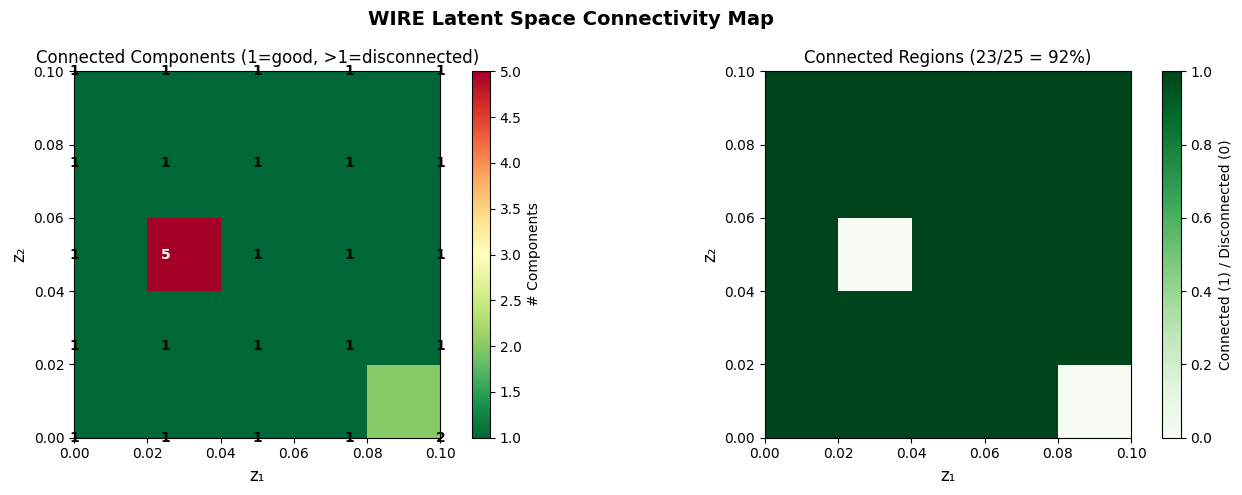


Latent space coverage: 92.0% connected


In [15]:
# Create 2D heatmap of connectivity across latent space
import matplotlib.pyplot as plt

connectivity_matrix = np.array(connectivity_grid).reshape(grid_size, grid_size)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Connectivity heatmap
ax1 = axes[0]
im1 = ax1.imshow(connectivity_matrix, origin='lower', cmap='RdYlGn_r', 
                  extent=[z_min, z_max, z_min, z_max], vmin=1, vmax=5)
ax1.set_xlabel('z₁', fontsize=12)
ax1.set_ylabel('z₂', fontsize=12)
ax1.set_title('Connected Components (1=good, >1=disconnected)', fontsize=12)
plt.colorbar(im1, ax=ax1, label='# Components')

# Add text annotations
for i in range(grid_size):
    for j in range(grid_size):
        val = connectivity_matrix[i, j]
        color = 'white' if val > 2 else 'black'
        ax1.text(z1_vals[j], z2_vals[i], f'{int(val)}', 
                ha='center', va='center', fontsize=10, color=color, fontweight='bold')

# Binary connectivity map
ax2 = axes[1]
binary_map = (connectivity_matrix == 1).astype(float)
im2 = ax2.imshow(binary_map, origin='lower', cmap='Greens', 
                  extent=[z_min, z_max, z_min, z_max], vmin=0, vmax=1)
ax2.set_xlabel('z₁', fontsize=12)
ax2.set_ylabel('z₂', fontsize=12)
ax2.set_title(f'Connected Regions ({int(binary_map.sum())}/{grid_size**2} = {100*binary_map.mean():.0f}%)', fontsize=12)
plt.colorbar(im2, ax=ax2, label='Connected (1) / Disconnected (0)')

plt.suptitle('WIRE Latent Space Connectivity Map', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLatent space coverage: {100*binary_map.mean():.1f}% connected")

## Latent Space Optimization — "Prompt Engineering for Geometry"

Instead of describing shapes in words, specify **measurable geometric properties** and optimize z to satisfy them.

```
min_z  Σᵢ λᵢ (gᵢ(f(z)) - tᵢ)²
```

Where:
- `f(z)` = decoder (WIRE network)
- `gᵢ` = geometric property functions (volume, curvature, etc.)
- `tᵢ` = target values

This is CLIP-guided editing, but for geometry.

In [16]:
# Latent Space Optimization Demo
import sys
sys.path.append('..')
import torch
import torch.nn.functional as F
from util.visualization.utils_mesh import get_watertight_mesh_for_latent
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials
from util.model_utils import tensor_product_xz
import numpy as np
import k3d
import trimesh

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load model
config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

model = get_model(**config['model'], use_legacy_gabor=True)
model.load_state_dict(torch.load('../checkpoints/GINN-model.pt', map_location=device))
model = model.to(device).eval()
netp = NetWithPartials.create_from_model(model, config['nz'], config['nx'])

print("Model loaded for latent optimization")

Model loaded for latent optimization


C:\Users\chukw\AppData\Local\Temp\ipykernel_40968\3969311547.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../checkpoints/GINN-model

In [17]:
# Define geometric property functions (differentiable where possible)

def compute_volume_proxy(model, z, bounds, n_samples=5000):
    """Approximate volume by sampling points and counting inside (SDF < 0)
    Uses soft threshold for differentiability"""
    # Sample random points in bounding box
    pts = torch.rand(n_samples, 3, device=z.device)
    pts = pts * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    
    # Evaluate SDF
    with torch.enable_grad():
        sdf = model(pts, z.unsqueeze(0).expand(n_samples, -1)).squeeze()
    
    # Soft inside indicator (sigmoid of -sdf)
    # temperature controls sharpness
    temperature = 10.0
    inside = torch.sigmoid(-sdf * temperature)
    
    # Volume = fraction of points inside * total bbox volume
    bbox_vol = (bounds[:, 1] - bounds[:, 0]).prod()
    volume = inside.mean() * bbox_vol
    return volume

def compute_centroid_z(model, z, bounds, n_samples=3000):
    """Compute centroid of shape (weighted by inside-ness)
    Returns z-coordinate of centroid"""
    pts = torch.rand(n_samples, 3, device=z.device)
    pts = pts * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    
    with torch.enable_grad():
        sdf = model(pts, z.unsqueeze(0).expand(n_samples, -1)).squeeze()
    
    inside = torch.sigmoid(-sdf * 10.0)
    centroid_z = (pts[:, 2] * inside).sum() / (inside.sum() + 1e-6)
    return centroid_z

def compute_symmetry_loss(model, z, bounds, n_samples=2000, axis=0):
    """Measure asymmetry by comparing f(x) vs f(flip(x))"""
    pts = torch.rand(n_samples, 3, device=z.device)
    pts = pts * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    
    # Flip along axis
    pts_flip = pts.clone()
    center = (bounds[axis, 0] + bounds[axis, 1]) / 2
    pts_flip[:, axis] = 2 * center - pts_flip[:, axis]
    
    with torch.enable_grad():
        sdf1 = model(pts, z.unsqueeze(0).expand(n_samples, -1)).squeeze()
        sdf2 = model(pts_flip, z.unsqueeze(0).expand(n_samples, -1)).squeeze()
    
    # Asymmetry = MSE between flipped SDFs
    asymmetry = F.mse_loss(sdf1, sdf2)
    return asymmetry

print("Geometric property functions defined:")
print("  - compute_volume_proxy(model, z, bounds)")
print("  - compute_centroid_z(model, z, bounds)")
print("  - compute_symmetry_loss(model, z, bounds)")

Geometric property functions defined:
  - compute_volume_proxy(model, z, bounds)
  - compute_centroid_z(model, z, bounds)
  - compute_symmetry_loss(model, z, bounds)


In [18]:
# Gradient-based latent optimization
# "Prompt": Find a shape with TARGET VOLUME

# Start from random z in valid range
z = torch.tensor([0.02, 0.08], device=device, requires_grad=True)

# Target properties - VOLUME FOCUSED
target_volume = 0.001  # Adjust this! Try 0.001 (small), 0.005 (medium), 0.01 (large)
lambda_volume = 100.0

optimizer = torch.optim.Adam([z], lr=0.01)

print("=== LATENT OPTIMIZATION: TARGET VOLUME ===")
print(f"Target volume = {target_volume}")
print(f"Starting z = {z.detach().tolist()}")
print()

history = []
for step in range(100):
    optimizer.zero_grad()
    
    # Clamp z to valid range during forward pass
    z_clamped = torch.clamp(z, 0.0, 0.1)
    
    # Compute volume
    vol = compute_volume_proxy(model, z_clamped, bounds, n_samples=3000)
    
    # Loss: match target volume
    loss = lambda_volume * (vol - target_volume) ** 2
    
    # Backward and step
    loss.backward()
    optimizer.step()
    
    # Clamp z to valid range
    with torch.no_grad():
        z.clamp_(0.0, 0.1)
    
    history.append({
        'step': step,
        'z': z.detach().clone(),
        'volume': vol.item(),
        'loss': loss.item()
    })
    
    if step % 20 == 0:
        print(f"Step {step:3d}: z=[{z[0].item():.4f}, {z[1].item():.4f}] | volume={vol.item():.5f} (target={target_volume}) | loss={loss.item():.6f}")

print()
print(f"Final z = [{z[0].item():.4f}, {z[1].item():.4f}]")
print(f"Final volume = {history[-1]['volume']:.5f} (target = {target_volume})")

=== LATENT OPTIMIZATION: TARGET VOLUME ===
Target volume = 0.001
Starting z = [0.019999999552965164, 0.07999999821186066]

Step   0: z=[0.0100, 0.0900] | volume=0.43366 (target=0.001) | loss=18.719498
Step  20: z=[0.0000, 0.1000] | volume=0.28084 (target=0.001) | loss=7.831074
Step  40: z=[0.0000, 0.1000] | volume=0.27842 (target=0.001) | loss=7.696294
Step  60: z=[0.0001, 0.1000] | volume=0.27655 (target=0.001) | loss=7.592515
Step  80: z=[0.0003, 0.1000] | volume=0.27923 (target=0.001) | loss=7.741078

Final z = [0.0000, 0.1000]
Final volume = 0.28372 (target = 0.001)


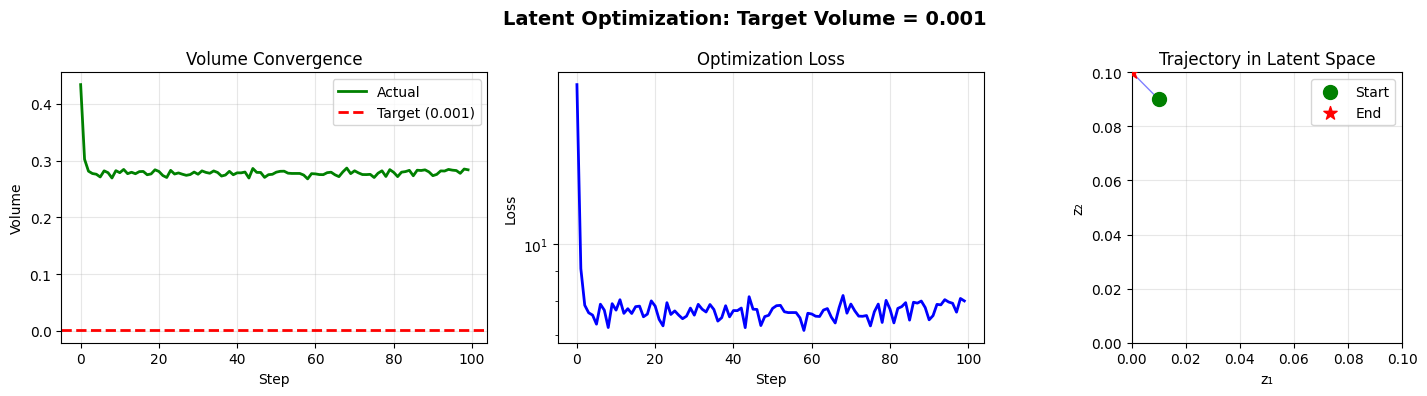

In [19]:
# Visualize the optimization trajectory and result
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Volume convergence
ax1 = axes[0]
ax1.plot([h['volume'] for h in history], 'g-', linewidth=2, label='Actual')
ax1.axhline(target_volume, color='r', linestyle='--', linewidth=2, label=f'Target ({target_volume})')
ax1.set_xlabel('Step')
ax1.set_ylabel('Volume')
ax1.set_title('Volume Convergence')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss curve
ax2 = axes[1]
ax2.plot([h['loss'] for h in history], 'b-', linewidth=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Optimization Loss')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# Trajectory in z-space
ax3 = axes[2]
z_traj = torch.stack([h['z'] for h in history]).cpu().numpy()
ax3.plot(z_traj[:, 0], z_traj[:, 1], 'b-', alpha=0.5, linewidth=1)
ax3.scatter(z_traj[0, 0], z_traj[0, 1], c='green', s=100, marker='o', label='Start', zorder=5)
ax3.scatter(z_traj[-1, 0], z_traj[-1, 1], c='red', s=100, marker='*', label='End', zorder=5)
ax3.set_xlim(0, 0.1)
ax3.set_ylim(0, 0.1)
ax3.set_xlabel('z₁')
ax3.set_ylabel('z₂')
ax3.set_title('Trajectory in Latent Space')
ax3.legend()
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Latent Optimization: Target Volume = {target_volume}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Compare: Starting shape vs Target Volume shape
mc_resolution = 128

# Starting shape
z_start = torch.tensor([0.02, 0.08], device=device)
mesh_start = get_watertight_mesh_for_latent(
    netp.f_, netp.params, z_start, bounds, mc_resolution, device,
    chunks=1, level=0, surpress_watertight=True
)

# Optimized shape
z_final = history[-1]['z']
mesh_final = get_watertight_mesh_for_latent(
    netp.f_, netp.params, z_final, bounds, mc_resolution, device,
    chunks=1, level=0, surpress_watertight=True
)

# Visualize side by side
spacing = 2.0 * (bounds[:, 1] - bounds[:, 0]).cpu().numpy()

fig = k3d.plot(height=600)

if len(mesh_start[0]) > 0:
    fig += k3d.mesh(*mesh_start, color=0x3498db, side='double', 
                    translation=[-spacing[0]/2, 0, 0],
                    name=f"Start z=[0.02, 0.08]")

if len(mesh_final[0]) > 0:
    fig += k3d.mesh(*mesh_final, color=0x2ecc71, side='double',
                    translation=[spacing[0]/2, 0, 0],
                    name=f"Target Vol z=[{z_final[0].item():.3f}, {z_final[1].item():.3f}]")

fig += k3d.text2d(f"LEFT=Start | RIGHT=Optimized (target vol={target_volume})", 
                  position=[0.2, 0.95], size=1.5, color=0x000000)
fig.display()

print(f"Start z = [0.02, 0.08]")
print(f"Optimized z = [{z_final[0].item():.4f}, {z_final[1].item():.4f}]")
print(f"\nVolume: {history[0]['volume']:.5f} → {history[-1]['volume']:.5f} (target = {target_volume})")

c:\Users\chukw\Desktop\Programming\GINNs-Geometry-informed-Neural-Networks\.venv\Lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

Start z = [0.02, 0.08]
Optimized z = [0.0000, 0.1000]

Volume: 0.43366 → 0.28372 (target = 0.001)
